# Sélection Définitive des Features — UNSW-NB15

Ce notebook produit la liste finale des features à utiliser dans les modèles, en combinant 4 méthodes de scoring + élimination de la redondance Pearson.

**Pipeline :**
1. Scoring : ANOVA + Information Mutuelle + Random Forest + Cramér's V
2. Ranking combiné normalisé
3. Seuil automatique de pertinence
4. Élimination des features redondantes (|Pearson| > seuil)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import f_oneway, chi2_contingency

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# ============================================================
# PARAMÈTRES DE SÉLECTION (modifiables)
# ============================================================
PEARSON_THRESHOLD = 0.85     # Seuil de redondance
MIN_SCORE_PERCENTILE = 25   # Garder les features au-dessus du 25e percentile

# Features à EXCLURE par design (identifiants, pas comportementaux)
BLACKLIST = ['sport', 'dsport', 'srcip', 'dstip', 'id', 'label',
             'stime', 'ltime']

print("✅ Configuration chargée")
print(f"   Seuil redondance Pearson : |r| > {PEARSON_THRESHOLD}")
print(f"   Seuil pertinence : percentile > {MIN_SCORE_PERCENTILE}")
print(f"   Blacklist (identifiants) : {BLACKLIST}")

✅ Configuration chargée
   Seuil redondance Pearson : |r| > 0.85
   Seuil pertinence : percentile > 25
   Blacklist (identifiants) : ['sport', 'dsport', 'srcip', 'dstip', 'id', 'label', 'stime', 'ltime']


In [ ]:
# ============================================================
# 1. CHARGEMENT ET NETTOYAGE
# ============================================================

# ⬇️ ADAPTER LE CHEMIN
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/combine_UNSW_clean1.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

TARGET = 'attack_cat'
df[TARGET] = df[TARGET].astype(str).str.strip()
df[TARGET] = df[TARGET].replace({
    'Backdoors': 'Backdoor',
    'Fuzzers ': 'Fuzzers',
    ' Reconnaissance ': 'Reconnaissance',
    ' Shellcode ': 'Shellcode'
})
df = df[df[TARGET].notna() & (df[TARGET] != 'nan')].copy()

# Séparer types
all_cols = [c for c in df.columns if c not in [TARGET] + BLACKLIST]
CAT_COLS = [c for c in all_cols if df[c].dtype == 'object']
NUM_COLS = [c for c in all_cols if c not in CAT_COLS]

# Forcer types numériques
for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[NUM_COLS] = df[NUM_COLS].fillna(0)

# Encoder cible
le_target = LabelEncoder()
y = le_target.fit_transform(df[TARGET])
class_names = le_target.classes_

print(f"Dataset : {df.shape[0]:,} lignes")
print(f"Features candidates : {len(NUM_COLS)} numériques + {len(CAT_COLS)} catégorielles")
print(f"Exclues (blacklist) : {[c for c in BLACKLIST if c in df.columns]}")
print(f"Classes : {list(class_names)}")

Dataset : 317,592 lignes
Features candidates : 35 numériques + 3 catégorielles
Exclues (blacklist) : ['sport', 'dsport', 'srcip', 'dstip', 'label', 'stime', 'ltime']
Classes : ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']


In [ ]:
# ============================================================
# 2. SCORING AUTOMATIQUE — 4 MÉTHODES
# ============================================================

ALL_FEATURES = NUM_COLS + CAT_COLS
scores = pd.DataFrame(index=ALL_FEATURES)

# --- 2a. ANOVA F-TEST (numériques uniquement) ---
print("[1/4] ANOVA F-Test...")
anova_scores = {}
for col in NUM_COLS:
    groups = [df[df[TARGET] == cat][col].dropna() for cat in class_names]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        if np.isfinite(f_stat):
            anova_scores[col] = f_stat
scores['ANOVA'] = pd.Series(anova_scores)

# --- 2b. INFORMATION MUTUELLE (toutes features) ---
print("[2/4] Information Mutuelle...")
df_encoded = df.copy()
for col in CAT_COLS:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X_mi = df_encoded[ALL_FEATURES].fillna(0)
n_sample = min(50_000, len(X_mi))
idx = np.random.RandomState(SEED).choice(len(X_mi), n_sample, replace=False)
discrete_mask = [False] * len(NUM_COLS) + [True] * len(CAT_COLS)

mi_scores = mutual_info_classif(
    X_mi.iloc[idx], y[idx],
    discrete_features=discrete_mask,
    random_state=SEED, n_neighbors=5
)
scores['MI'] = pd.Series(mi_scores, index=ALL_FEATURES)

# --- 2c. RANDOM FOREST IMPORTANCE ---
print("[3/4] Random Forest Importance...")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=20,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf.fit(df_encoded[ALL_FEATURES].fillna(0), y)
scores['RF'] = pd.Series(rf.feature_importances_, index=ALL_FEATURES)

# --- 2d. CRAMÉR'S V (catégorielles uniquement) ---
print("[4/4] Cramér's V...")
def cramers_v(x, y_col):
    ct = pd.crosstab(x, y_col)
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2 / denom) if denom > 0 else 0.0

for col in CAT_COLS:
    scores.loc[col, 'CramerV'] = cramers_v(df[col].astype(str), df[TARGET].astype(str))

print("✅ 4 méthodes calculées")
print(scores.head())

[1/4] ANOVA F-Test...
[2/4] Information Mutuelle...
[3/4] Random Forest Importance...
[4/4] Cramér's V...
✅ 4 méthodes calculées
               ANOVA        MI        RF  CramerV
dur      1786.060945  0.260318  0.022391      NaN
sbytes    175.955437  0.750459  0.150209      NaN
dbytes    157.675960  0.311241  0.037446      NaN
sttl    18034.658551  0.110120  0.025374      NaN
dttl    32160.948230  0.218716  0.002404      NaN



📊 Seuil de pertinence (percentile 25) : 0.162
   Features pertinentes : 28
   Features éliminées (score trop faible) : 10


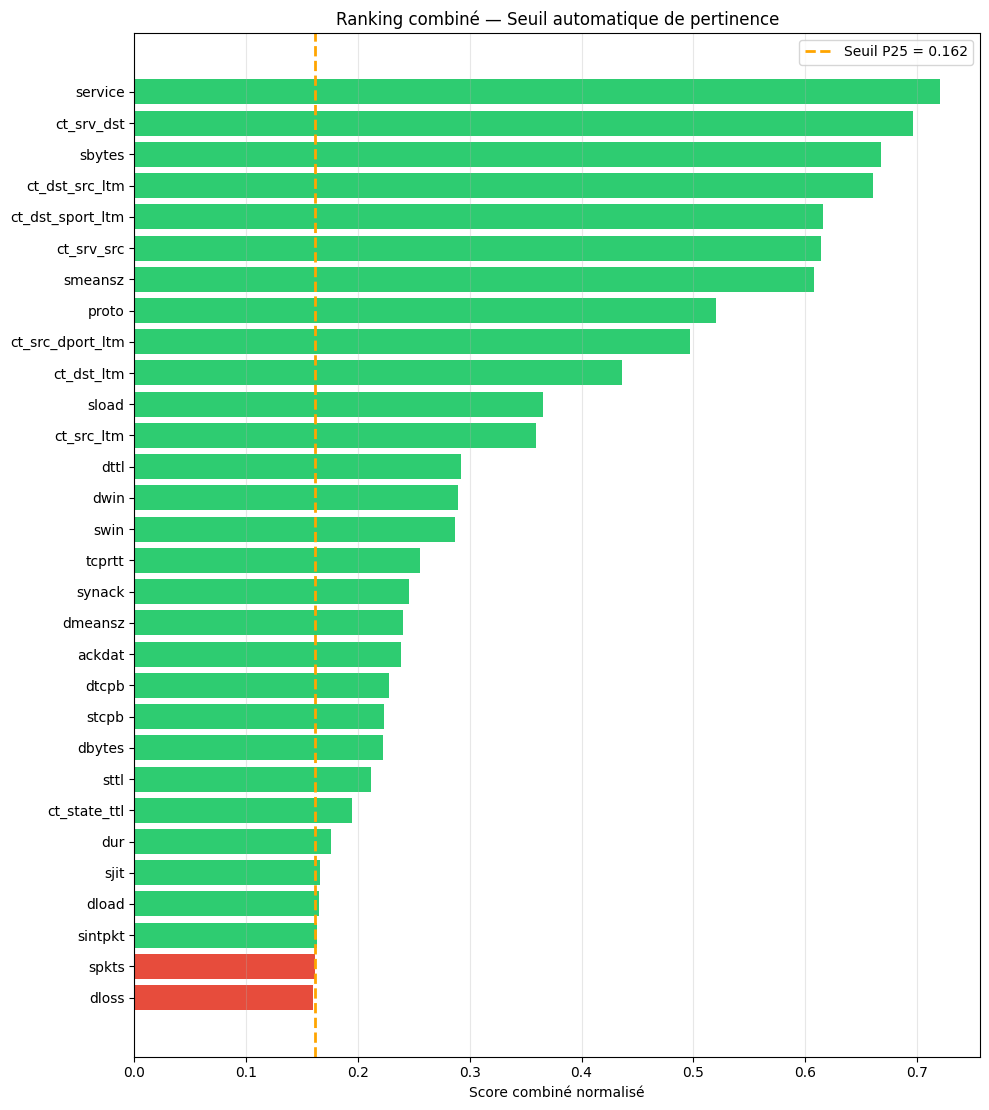


❌ Éliminées (score < 0.162) :
   spkts                      score = 0.161
   dloss                      score = 0.160
   sloss                      score = 0.155
   dpkts                      score = 0.151
   dintpkt                    score = 0.146
   djit                       score = 0.143
   state                      score = 0.103
   trans_depth                score = 0.077
   res_bdy_len                score = 0.037
   is_sm_ips                  score = 0.000


In [ ]:
# ============================================================
# 3. RANKING COMBINÉ NORMALISÉ
# ============================================================

# Normalisation min-max par méthode
scores_norm = scores.copy()
for col in scores_norm.columns:
    s = scores_norm[col].dropna()
    if s.max() > s.min():
        scores_norm[col] = (scores_norm[col] - s.min()) / (s.max() - s.min())
    else:
        scores_norm[col] = 0

# Score combiné = moyenne des méthodes disponibles (ignore NaN)
scores_norm['Score_Combiné'] = scores_norm.mean(axis=1, skipna=True)
scores_norm = scores_norm.sort_values('Score_Combiné', ascending=False)

# --- Seuil automatique : garder au-dessus du percentile ---
threshold = np.percentile(
    scores_norm['Score_Combiné'].dropna(),
    MIN_SCORE_PERCENTILE
)

pertinent = scores_norm[scores_norm['Score_Combiné'] >= threshold].index.tolist()
eliminated_score = scores_norm[scores_norm['Score_Combiné'] < threshold].index.tolist()

print(f"\n📊 Seuil de pertinence (percentile {MIN_SCORE_PERCENTILE}) : {threshold:.3f}")
print(f"   Features pertinentes : {len(pertinent)}")
print(f"   Features éliminées (score trop faible) : {len(eliminated_score)}")

# --- Visualisation ---
fig, ax = plt.subplots(figsize=(10, max(8, len(pertinent) * 0.4)))
top = scores_norm.head(30)
colors = ['#2ecc71' if f in pertinent else '#e74c3c' for f in top.index]
ax.barh(range(len(top)), top['Score_Combiné'].values, color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index)
ax.invert_yaxis()
ax.axvline(x=threshold, color='orange', linestyle='--', linewidth=2,
           label=f'Seuil P{MIN_SCORE_PERCENTILE} = {threshold:.3f}')
ax.set_xlabel('Score combiné normalisé')
ax.set_title('Ranking combiné — Seuil automatique de pertinence')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

if eliminated_score:
    print(f"\n❌ Éliminées (score < {threshold:.3f}) :")
    for f in eliminated_score:
        print(f"   {f:25s}  score = {scores_norm.loc[f, 'Score_Combiné']:.3f}")

In [ ]:
# ============================================================
# 4. ÉLIMINATION DE LA REDONDANCE (Pearson)
# ============================================================

# On ne travaille que sur les features numériques pertinentes
pertinent_num = [f for f in pertinent if f in NUM_COLS]
pertinent_cat = [f for f in pertinent if f in CAT_COLS]

print(f"Avant dé-redondance : {len(pertinent_num)} numériques + {len(pertinent_cat)} catégorielles")
print(f"Seuil Pearson : |r| > {PEARSON_THRESHOLD}\n")

# Matrice de corrélation
corr = df[pertinent_num].corr(method='pearson').abs()

# Algorithme glouton : pour chaque paire corrélée, supprimer
# celle avec le score combiné le plus faible
to_remove = set()
removal_reasons = {}

for i in range(len(pertinent_num)):
    if pertinent_num[i] in to_remove:
        continue
    for j in range(i + 1, len(pertinent_num)):
        if pertinent_num[j] in to_remove:
            continue
        r = corr.iloc[i, j]
        if r > PEARSON_THRESHOLD:
            f1, f2 = pertinent_num[i], pertinent_num[j]
            s1 = scores_norm.loc[f1, 'Score_Combiné']
            s2 = scores_norm.loc[f2, 'Score_Combiné']
            # Supprimer celle avec le score le plus faible
            if s1 >= s2:
                to_remove.add(f2)
                removal_reasons[f2] = f"corr {r:.2f} avec {f1} (score {s1:.3f} > {s2:.3f})"
            else:
                to_remove.add(f1)
                removal_reasons[f1] = f"corr {r:.2f} avec {f2} (score {s2:.3f} > {s1:.3f})"

final_num = [f for f in pertinent_num if f not in to_remove]
final_cat = pertinent_cat  # Les catégorielles ne sont pas concernées par Pearson

print(f"🔴 Features supprimées pour redondance ({len(to_remove)}) :")
for f in sorted(to_remove):
    print(f"   {f:25s} → {removal_reasons[f]}")

print(f"\n✅ Après dé-redondance : {len(final_num)} numériques + {len(final_cat)} catégorielles")

Avant dé-redondance : 26 numériques + 2 catégorielles
Seuil Pearson : |r| > 0.85

🔴 Features supprimées pour redondance (8) :
   ackdat                    → corr 0.87 avec dttl (score 0.292 > 0.239)
   ct_dst_ltm                → corr 0.86 avec ct_dst_sport_ltm (score 0.616 > 0.436)
   ct_dst_src_ltm            → corr 0.99 avec ct_srv_dst (score 0.697 > 0.661)
   ct_src_dport_ltm          → corr 0.87 avec ct_dst_sport_ltm (score 0.616 > 0.497)
   ct_srv_src                → corr 1.00 avec ct_srv_dst (score 0.697 > 0.614)
   dwin                      → corr 1.00 avec dttl (score 0.292 > 0.289)
   swin                      → corr 1.00 avec dttl (score 0.292 > 0.287)
   tcprtt                    → corr 0.87 avec dttl (score 0.292 > 0.255)

✅ Après dé-redondance : 18 numériques + 2 catégorielles


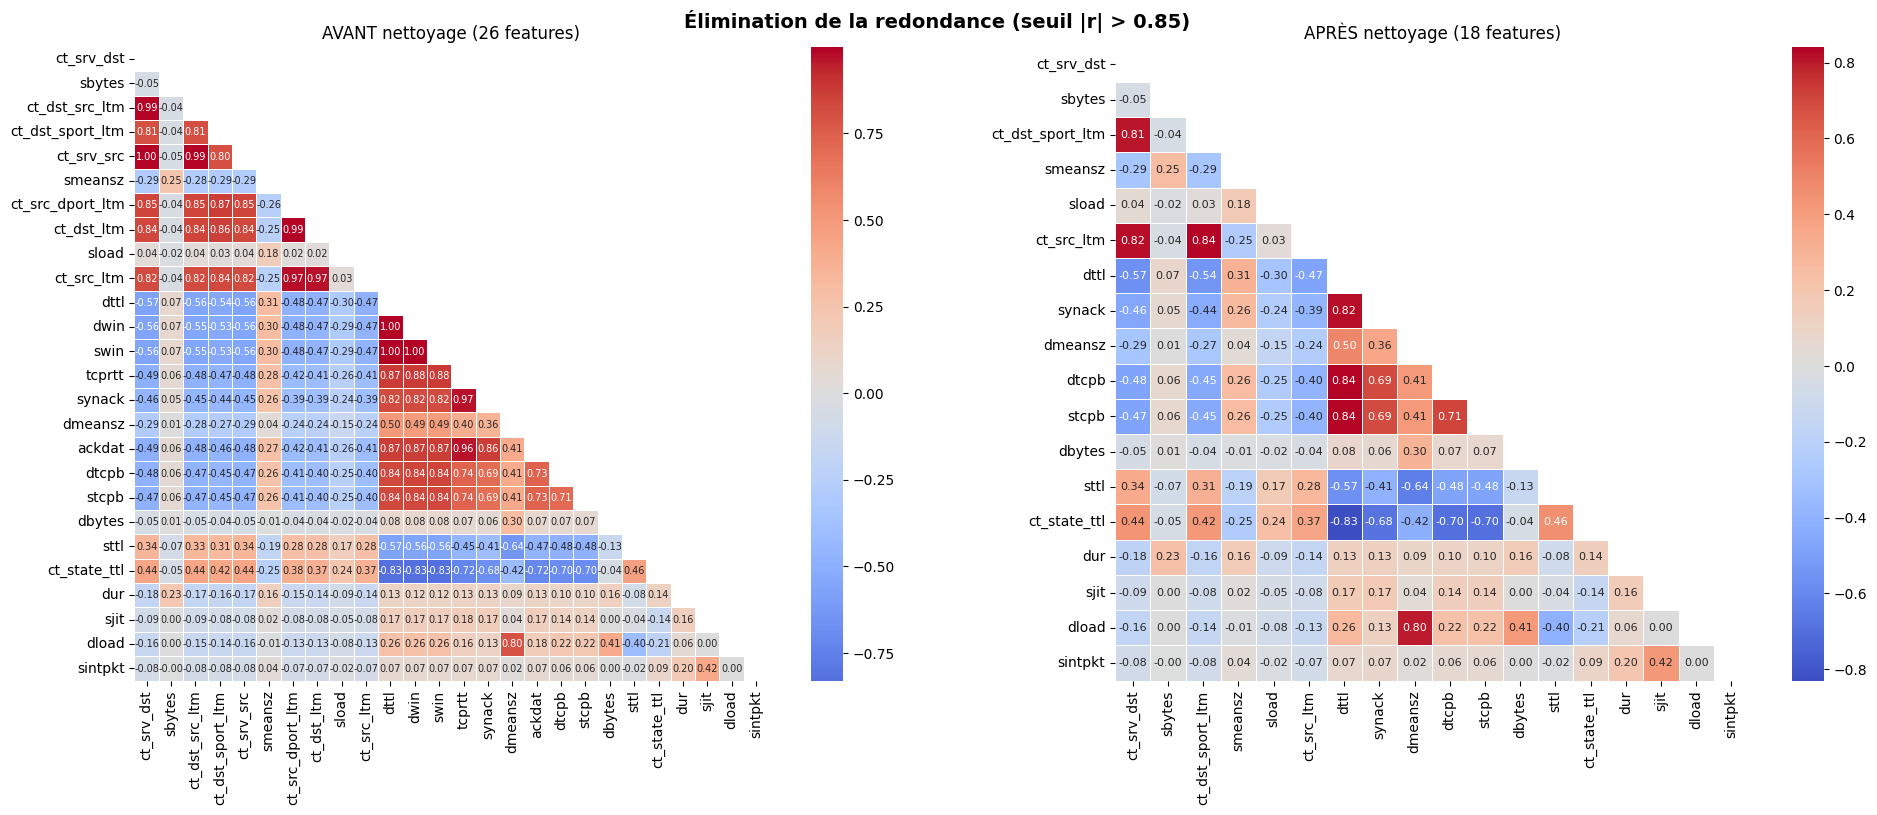


Corrélation max restante : 0.842
✅ Aucune redondance restante


In [ ]:
# ============================================================
# 5. VÉRIFICATION VISUELLE — Heatmap finale
# ============================================================

if len(final_num) > 1:
    corr_final = df[final_num].corr(method='pearson')

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # AVANT
    corr_before = df[pertinent_num].corr(method='pearson')
    mask1 = np.triu(np.ones_like(corr_before, dtype=bool))
    sns.heatmap(corr_before, mask=mask1, cmap='coolwarm', center=0,
                annot=True, fmt='.2f', annot_kws={'size': 7},
                square=True, ax=axes[0], linewidths=0.5)
    axes[0].set_title(f'AVANT nettoyage ({len(pertinent_num)} features)')

    # APRÈS
    mask2 = np.triu(np.ones_like(corr_final, dtype=bool))
    sns.heatmap(corr_final, mask=mask2, cmap='coolwarm', center=0,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                square=True, ax=axes[1], linewidths=0.5)
    axes[1].set_title(f'APRÈS nettoyage ({len(final_num)} features)')

    plt.suptitle(f'Élimination de la redondance (seuil |r| > {PEARSON_THRESHOLD})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Vérifier qu'il ne reste plus de corrélation forte
    max_corr = corr_final.where(
        np.triu(np.ones_like(corr_final, dtype=bool), k=1)
    ).max().max()
    print(f"\nCorrélation max restante : {max_corr:.3f}")
    if max_corr <= PEARSON_THRESHOLD:
        print("✅ Aucune redondance restante")
    else:
        print(f"⚠️ Il reste des paires > {PEARSON_THRESHOLD} — ajuster le seuil ou vérifier manuellement")

In [ ]:
# ============================================================
# 6. RÉSULTAT FINAL — COPIER-COLLER POUR TES MODÈLES
# ============================================================

print("=" * 60)
print("📋 SÉLECTION FINALE DES FEATURES")
print("=" * 60)

print(f"\n# {len(final_num)} features numériques :")
print(f"NUM_COLS = {final_num}")

print(f"\n# {len(final_cat)} features catégorielles :")
print(f"CAT_COLS = {final_cat}")

print(f"\n# Total : {len(final_num) + len(final_cat)} features")

# --- Tableau récapitulatif ---
print("\n" + "-" * 70)
print(f"{'Feature':25s} {'Type':6s} {'Score':>8s} {'ANOVA':>8s} {'MI':>8s} {'RF':>8s} {'Status'}")
print("-" * 70)

for feat in scores_norm.index:
    ftype = 'CAT' if feat in CAT_COLS else 'NUM'
    sc = scores_norm.loc[feat, 'Score_Combiné']
    anova = scores_norm.loc[feat, 'ANOVA'] if pd.notna(scores_norm.loc[feat, 'ANOVA']) else '-'
    mi = scores_norm.loc[feat, 'MI'] if pd.notna(scores_norm.loc[feat, 'MI']) else '-'
    rfv = scores_norm.loc[feat, 'RF'] if pd.notna(scores_norm.loc[feat, 'RF']) else '-'

    if feat in final_num or feat in final_cat:
        status = '✅ GARDÉE'
    elif feat in to_remove:
        status = '🔴 REDONDANTE'
    elif feat in eliminated_score:
        status = '⚪ SCORE FAIBLE'
    elif feat in BLACKLIST:
        status = '⛔ BLACKLIST'
    else:
        status = '❓'

    anova_str = f"{anova:>8.3f}" if isinstance(anova, float) else f"{anova:>8s}"
    mi_str = f"{mi:>8.3f}" if isinstance(mi, float) else f"{mi:>8s}"
    rf_str = f"{rfv:>8.3f}" if isinstance(rfv, float) else f"{rfv:>8s}"

    print(f"{feat:25s} {ftype:6s} {sc:>8.3f} {anova_str} {mi_str} {rf_str} {status}")

📋 SÉLECTION FINALE DES FEATURES

# 18 features numériques :
NUM_COLS = ['ct_srv_dst', 'sbytes', 'ct_dst_sport_ltm', 'smeansz', 'sload', 'ct_src_ltm', 'dttl', 'synack', 'dmeansz', 'dtcpb', 'stcpb', 'dbytes', 'sttl', 'ct_state_ttl', 'dur', 'sjit', 'dload', 'sintpkt']

# 2 features catégorielles :
CAT_COLS = ['service', 'proto']

# Total : 20 features

----------------------------------------------------------------------
Feature                   Type      Score    ANOVA       MI       RF Status
----------------------------------------------------------------------
service                   CAT       0.720        -    0.785    0.376 ✅ GARDÉE
ct_srv_dst                NUM       0.697    1.000    0.681    0.409 ✅ GARDÉE
sbytes                    NUM       0.667    0.002    1.000    1.000 ✅ GARDÉE
ct_dst_src_ltm            NUM       0.661    0.943    0.637    0.403 🔴 REDONDANTE
ct_dst_sport_ltm          NUM       0.616    0.921    0.653    0.276 ✅ GARDÉE
ct_srv_src                NUM       

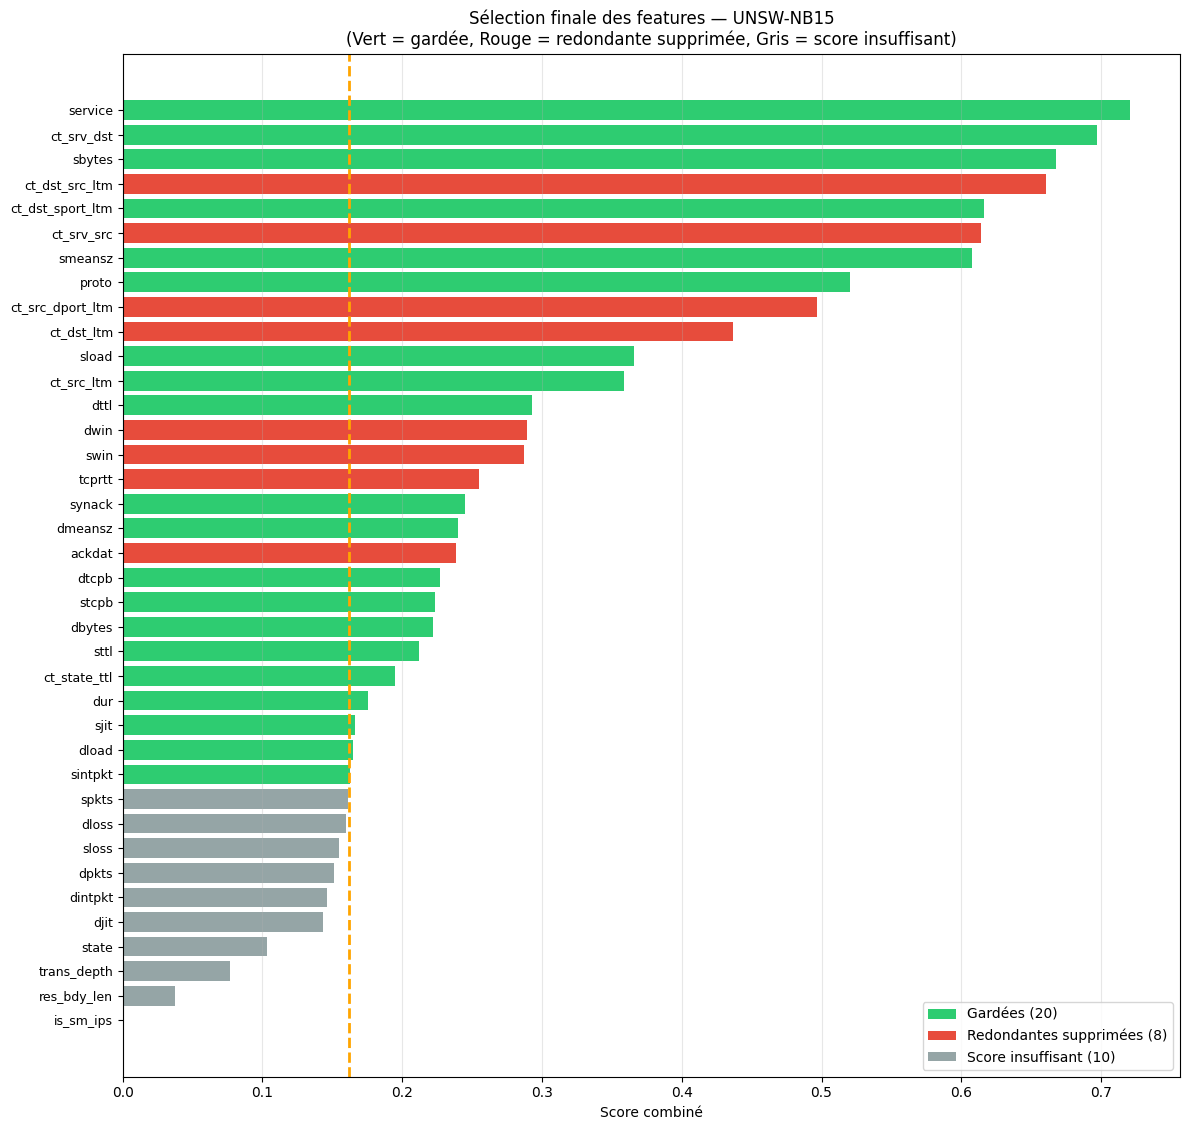


📋 CODE À COPIER DANS VOS MODÈLES :

NUM_COLS = ['ct_srv_dst', 'sbytes', 'ct_dst_sport_ltm', 'smeansz', 'sload', 'ct_src_ltm', 'dttl', 'synack', 'dmeansz', 'dtcpb', 'stcpb', 'dbytes', 'sttl', 'ct_state_ttl', 'dur', 'sjit', 'dload', 'sintpkt']

CAT_COLS = ['service', 'proto']

# Total : 20 features
# Redondantes éliminées : 8
# Score trop faible : 10
# Blacklistées (identifiants) : 7


In [ ]:
# ============================================================
# 7. GRAPHIQUE RÉCAPITULATIF FINAL
# ============================================================

fig, ax = plt.subplots(figsize=(12, max(8, len(scores_norm) * 0.3)))

all_feats = scores_norm.index.tolist()
all_scores = scores_norm['Score_Combiné'].values

colors = []
for f in all_feats:
    if f in final_num or f in final_cat:
        colors.append('#2ecc71')   # Vert = gardée
    elif f in to_remove:
        colors.append('#e74c3c')   # Rouge = redondante
    elif f in eliminated_score:
        colors.append('#95a5a6')   # Gris = score faible
    else:
        colors.append('#f39c12')   # Orange = autre

ax.barh(range(len(all_feats)), all_scores, color=colors)
ax.set_yticks(range(len(all_feats)))
ax.set_yticklabels(all_feats, fontsize=9)
ax.invert_yaxis()
ax.axvline(x=threshold, color='orange', linestyle='--', linewidth=2)
ax.set_xlabel('Score combiné')
ax.set_title('Sélection finale des features — UNSW-NB15\n'
             '(Vert = gardée, Rouge = redondante supprimée, Gris = score insuffisant)',
             fontsize=12)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend = [
    Patch(facecolor='#2ecc71', label=f'Gardées ({len(final_num) + len(final_cat)})'),
    Patch(facecolor='#e74c3c', label=f'Redondantes supprimées ({len(to_remove)})'),
    Patch(facecolor='#95a5a6', label=f'Score insuffisant ({len(eliminated_score)})'),
]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

# --- Code prêt à copier ---
print("\n" + "=" * 60)
print("📋 CODE À COPIER DANS VOS MODÈLES :")
print("=" * 60)
print(f"\nNUM_COLS = {final_num}")
print(f"\nCAT_COLS = {final_cat}")
print(f"\n# Total : {len(final_num) + len(final_cat)} features")
print(f"# Redondantes éliminées : {len(to_remove)}")
print(f"# Score trop faible : {len(eliminated_score)}")
print(f"# Blacklistées (identifiants) : {len([c for c in BLACKLIST if c in df.columns])}")